# 3-Class Classification Baseline

This notebook trains baseline models for 3-class readmission prediction:
- Class 0: NO (not readmitted)
- Class 1: >30 (readmitted after 30 days)
- Class 2: <30 (readmitted within 30 days)

We compare Logistic Regression, XGBoost, Decision Tree, and Random Forest.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from src.feature_engineering_multiclass import feature_engineering_multiclass

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load and Prepare Data

In [2]:
# Load preprocessed data with 3-class target
X_train, X_val, X_test, y_train, y_val, y_test, scaler = feature_engineering_multiclass()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 81393 samples, 212 features
Validation set: 10174 samples
Test set: 10175 samples


In [3]:
# Check class distribution
class_names = {0: 'NO (not readmitted)', 1: '>30 days', 2: '<30 days'}

print("Class distribution in training set:")
print("-" * 40)
for cls, name in class_names.items():
    count = (y_train == cls).sum()
    pct = count / len(y_train) * 100
    print(f"  {cls} ({name}): {count:,} ({pct:.1f}%)")

print(f"\nClass imbalance ratio (majority/minority): {y_train.value_counts().max() / y_train.value_counts().min():.1f}x")

Class distribution in training set:
----------------------------------------
  0 (NO (not readmitted)): 43,879 (53.9%)
  1 (>30 days): 28,433 (34.9%)
  2 (<30 days): 9,081 (11.2%)

Class imbalance ratio (majority/minority): 4.8x


In [4]:
# Feature selection (same approach as binary classification for fair comparison)
groups = {}
for col in X_train.columns:
    base = re.sub(r'_[^_]+$', '', col)
    groups.setdefault(base, []).append(col)

# Use RF for feature importance
selector_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
selector_model.fit(X_train, y_train)

importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(25).index

# Include all columns from same categorical group
final_features = set()
for g, cols in groups.items():
    if any(c in top_features for c in cols):
        final_features.update(cols)

X_train = X_train[list(final_features)]
X_val = X_val[list(final_features)]
X_test = X_test[list(final_features)]

print(f"Selected {len(final_features)} features after grouping")

Selected 155 features after grouping


In [5]:
# Clean column names for XGBoost
for df in [X_train, X_val, X_test]:
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]

## 2. MLflow Setup

In [6]:
# Configure MLflow
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("multiclass-baseline")

print("MLflow configured")
print("Experiment: multiclass-baseline")

2025/12/19 16:58:09 INFO mlflow.tracking.fluent: Experiment with name 'multiclass-baseline' does not exist. Creating a new experiment.


MLflow configured
Experiment: multiclass-baseline


## 3. Train Baseline Models

In [7]:
# Define models
# Using class_weight='balanced' where available to handle imbalance
models = {
    "Logistic_Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        "log_function": mlflow.sklearn.log_model
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='mlogloss',
            use_label_encoder=False
        ),
        "log_function": mlflow.xgboost.log_model
    },
    "Decision_Tree": {
        "model": DecisionTreeClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        "log_function": mlflow.sklearn.log_model
    },
    "Random_Forest": {
        "model": RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        "log_function": mlflow.sklearn.log_model
    }
}

# Store results
results = {}

In [8]:
# Train and evaluate each model
for model_name, model_config in models.items():
    print(f"\nTraining {model_name}...")
    print("=" * 50)

    with mlflow.start_run(run_name=f"{model_name}_3class"):
        model = model_config["model"]
        log_function = model_config["log_function"]

        # Log configuration
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("num_classes", 3)
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("val_size", len(X_val))
        mlflow.set_tag("task", "multiclass")
        mlflow.set_tag("stage", "baseline")

        # Log model-specific parameters
        for param_name, param_value in model.get_params().items():
            mlflow.log_param(param_name, param_value)

        # Train
        model.fit(X_train, y_train)

        # Predict on validation set
        predictions = model.predict(X_val)

        # Calculate metrics (using weighted average for multiclass)
        accuracy = accuracy_score(y_val, predictions)
        f1_weighted = f1_score(y_val, predictions, average='weighted')
        f1_macro = f1_score(y_val, predictions, average='macro')
        precision_weighted = precision_score(y_val, predictions, average='weighted')
        recall_weighted = recall_score(y_val, predictions, average='weighted')

        # Per-class F1 scores
        f1_per_class = f1_score(y_val, predictions, average=None)

        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_weighted", f1_weighted)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("precision_weighted", precision_weighted)
        mlflow.log_metric("recall_weighted", recall_weighted)
        mlflow.log_metric("f1_class_0_no", f1_per_class[0])
        mlflow.log_metric("f1_class_1_over30", f1_per_class[1])
        mlflow.log_metric("f1_class_2_under30", f1_per_class[2])

        # Log model
        log_function(model, model_name.lower())

        # Store results
        results[model_name] = {
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'f1_class_0': f1_per_class[0],
            'f1_class_1': f1_per_class[1],
            'f1_class_2': f1_per_class[2],
            'model': model
        }

        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 (weighted): {f1_weighted:.4f}")
        print(f"F1 (macro): {f1_macro:.4f}")
        print(f"Per-class F1: NO={f1_per_class[0]:.4f}, >30={f1_per_class[1]:.4f}, <30={f1_per_class[2]:.4f}")


Training Logistic_Regression...


2025/12/19 16:59:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:59:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.4849
F1 (weighted): 0.4967
F1 (macro): 0.4106
Per-class F1: NO=0.6435, >30=0.3539, <30=0.2343
🏃 View run Logistic_Regression_3class at: http://localhost:5000/#/experiments/822966513567142168/runs/37b2569b606e4c95bf732fa05456507a
🧪 View experiment at: http://localhost:5000/#/experiments/822966513567142168

Training XGBoost...


2025/12/19 16:59:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:59:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.5833
F1 (weighted): 0.5337
F1 (macro): 0.3894
Per-class F1: NO=0.7084, >30=0.4226, <30=0.0370
🏃 View run XGBoost_3class at: http://localhost:5000/#/experiments/822966513567142168/runs/7676803aa26d43f8a7dd47d859ad7c27
🧪 View experiment at: http://localhost:5000/#/experiments/822966513567142168

Training Decision_Tree...


2025/12/19 16:59:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 16:59:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.4632
F1 (weighted): 0.4656
F1 (macro): 0.3699
Per-class F1: NO=0.5858, >30=0.3842, <30=0.1398
🏃 View run Decision_Tree_3class at: http://localhost:5000/#/experiments/822966513567142168/runs/34262181e44846a5aaf24d06683a9f75
🧪 View experiment at: http://localhost:5000/#/experiments/822966513567142168

Training Random_Forest...


2025/12/19 17:00:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/19 17:00:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.5773
F1 (weighted): 0.5256
F1 (macro): 0.3805
Per-class F1: NO=0.7047, >30=0.4081, <30=0.0286
🏃 View run Random_Forest_3class at: http://localhost:5000/#/experiments/822966513567142168/runs/c4015f1c1119423e9f0546a218a3f92e
🧪 View experiment at: http://localhost:5000/#/experiments/822966513567142168


## 4. Results Comparison

In [9]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 (weighted)': [r['f1_weighted'] for r in results.values()],
    'F1 (macro)': [r['f1_macro'] for r in results.values()],
    'F1 NO': [r['f1_class_0'] for r in results.values()],
    'F1 >30': [r['f1_class_1'] for r in results.values()],
    'F1 <30': [r['f1_class_2'] for r in results.values()]
}).round(4)

print("3-Class Baseline Results (Validation Set)")
print("=" * 80)
print(comparison_df.to_string(index=False))

3-Class Baseline Results (Validation Set)
              Model  Accuracy  F1 (weighted)  F1 (macro)  F1 NO  F1 >30  F1 <30
Logistic_Regression    0.4849         0.4967      0.4106 0.6435  0.3539  0.2343
            XGBoost    0.5833         0.5337      0.3894 0.7084  0.4226  0.0370
      Decision_Tree    0.4632         0.4656      0.3699 0.5858  0.3842  0.1398
      Random_Forest    0.5773         0.5256      0.3805 0.7047  0.4081  0.0286


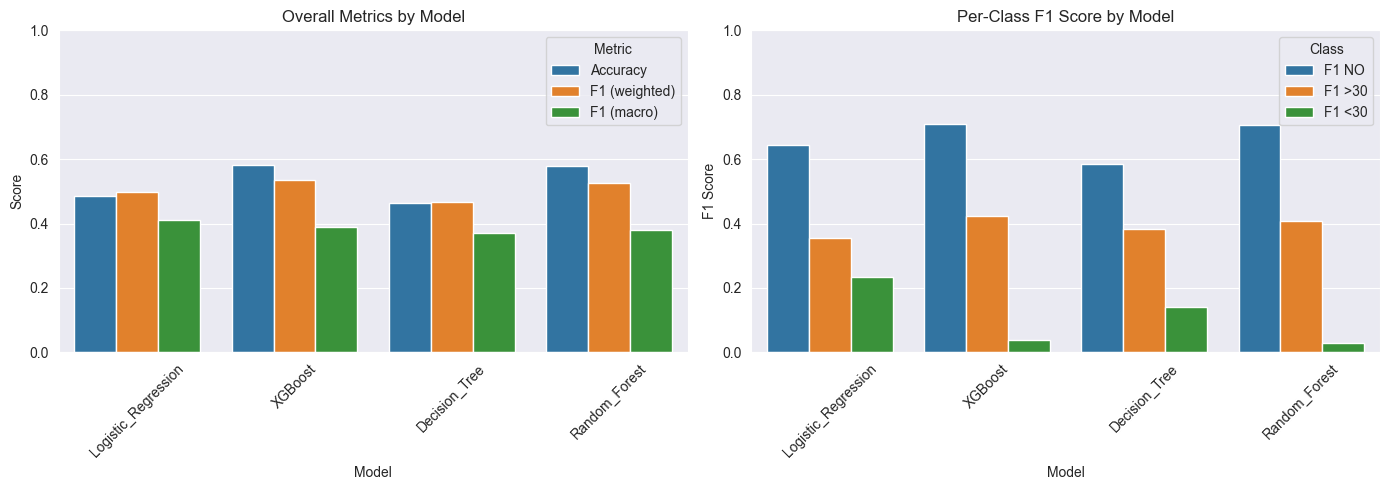

In [10]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall metrics
metrics_df = comparison_df[['Model', 'Accuracy', 'F1 (weighted)', 'F1 (macro)']].melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', ax=axes[0])
axes[0].set_title('Overall Metrics by Model')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Per-class F1 scores
class_df = comparison_df[['Model', 'F1 NO', 'F1 >30', 'F1 <30']].melt(
    id_vars='Model', var_name='Class', value_name='F1 Score'
)
sns.barplot(data=class_df, x='Model', y='F1 Score', hue='Class', ax=axes[1])
axes[1].set_title('Per-Class F1 Score by Model')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('multiclass_baseline_comparison.png', dpi=150)
plt.show()

In [11]:
# Find best model based on macro F1 (treats all classes equally)
best_model_name = max(results, key=lambda x: results[x]['f1_macro'])
best_model = results[best_model_name]['model']

print(f"Best model (by macro F1): {best_model_name}")
print(f"Macro F1: {results[best_model_name]['f1_macro']:.4f}")

Best model (by macro F1): Logistic_Regression
Macro F1: 0.4106


## 5. Detailed Evaluation of Best Model

In [12]:
# Classification report for best model
best_pred = best_model.predict(X_val)

print(f"Classification Report - {best_model_name}")
print("=" * 60)
print(classification_report(
    y_val, best_pred,
    target_names=['NO (not readmitted)', '>30 days', '<30 days']
))

Classification Report - Logistic_Regression
                     precision    recall  f1-score   support

NO (not readmitted)       0.66      0.63      0.64      5485
           >30 days       0.46      0.29      0.35      3554
           <30 days       0.17      0.39      0.23      1135

           accuracy                           0.48     10174
          macro avg       0.43      0.44      0.41     10174
       weighted avg       0.53      0.48      0.50     10174



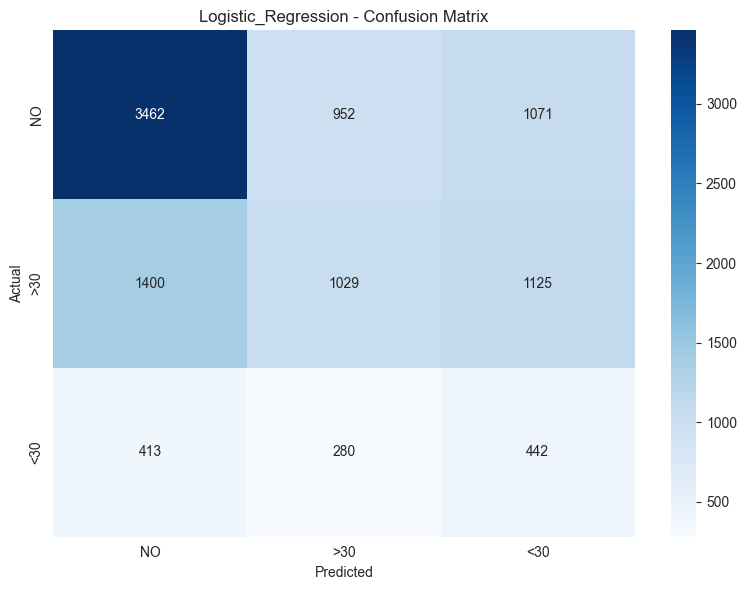

In [13]:
# Confusion matrix for best model
cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NO', '>30', '<30'],
    yticklabels=['NO', '>30', '<30']
)
plt.title(f'{best_model_name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('multiclass_confusion_matrix.png', dpi=150)
plt.show()

## 6. Log Summary to MLflow

In [14]:
# Log comparison summary
with mlflow.start_run(run_name="multiclass_comparison_summary"):
    mlflow.log_param("comparison_type", "3-class baseline")
    mlflow.log_param("num_models", len(models))
    mlflow.log_param("best_model", best_model_name)
    mlflow.set_tag("task", "multiclass")
    mlflow.set_tag("stage", "comparison")

    # Log best metrics
    mlflow.log_metric("best_accuracy", results[best_model_name]['accuracy'])
    mlflow.log_metric("best_f1_weighted", results[best_model_name]['f1_weighted'])
    mlflow.log_metric("best_f1_macro", results[best_model_name]['f1_macro'])

    # Save and log comparison table
    comparison_df.to_csv('multiclass_baseline_results.csv', index=False)
    mlflow.log_artifact('multiclass_baseline_results.csv')
    mlflow.log_artifact('multiclass_baseline_comparison.png')
    mlflow.log_artifact('multiclass_confusion_matrix.png')

print("Summary logged to MLflow")

🏃 View run multiclass_comparison_summary at: http://localhost:5000/#/experiments/822966513567142168/runs/f3675ddbf5a3402ca594035add0e3426
🧪 View experiment at: http://localhost:5000/#/experiments/822966513567142168
Summary logged to MLflow


## 7. Summary

This notebook established baseline performance for 3-class readmission prediction.

Key observations:
- Class 2 (<30 days) is the hardest to predict due to severe imbalance (11%)
- Macro F1 is more informative than weighted F1 for imbalanced multiclass
- All results tracked in MLflow experiment: `multiclass-baseline`


In [15]:
# Final summary
print("=" * 60)
print("3-CLASS BASELINE SUMMARY")
print("=" * 60)
print(f"\nBest Model: {best_model_name}")
print(f"\nValidation Metrics:")
print(f"  Accuracy:     {results[best_model_name]['accuracy']:.4f}")
print(f"  F1 (weighted): {results[best_model_name]['f1_weighted']:.4f}")
print(f"  F1 (macro):    {results[best_model_name]['f1_macro']:.4f}")
print(f"\nPer-class F1:")
print(f"  Class 0 (NO):  {results[best_model_name]['f1_class_0']:.4f}")
print(f"  Class 1 (>30): {results[best_model_name]['f1_class_1']:.4f}")
print(f"  Class 2 (<30): {results[best_model_name]['f1_class_2']:.4f}")
print(f"\nMLflow: http://localhost:5000 -> multiclass-baseline")

3-CLASS BASELINE SUMMARY

Best Model: Logistic_Regression

Validation Metrics:
  Accuracy:     0.4849
  F1 (weighted): 0.4967
  F1 (macro):    0.4106

Per-class F1:
  Class 0 (NO):  0.6435
  Class 1 (>30): 0.3539
  Class 2 (<30): 0.2343

MLflow: http://localhost:5000 -> multiclass-baseline
